# H1 — Connected pairs have higher F_corr than unconnected pairs
## Person 4 — 93-neuron L4-V1 sanity check + 906-neuron V1/RL/AL area comparison

**Scope.** Two tasks:
1. **93-neuron scan-9.3 sanity check** (§2–§7) — tests H1 on the homogeneous L4-V1 subset using the co-recorded trace-correlation matrix.
2. **Optional: true noise-correlation analysis** (§7.5) — decomposes the trace-correlation into signal and noise components.
3. **V1 / RL / AL exploratory comparisons** (§8) — re-runs H1 within and across brain areas using the 906-neuron signal-correlation cohort.

**Important labelling note.** The 93-neuron `F_correlation_matrix.npy` is built from `np.corrcoef(raw_traces)` across 464 co-recorded trials — that is **trace correlation** (signal + noise mixed), *not* signal correlation. In contrast, the 906-neuron `F_906.npy` averages over stimulus repeats before correlating, so those values are proper **signal correlations**. The two measures are related but not identical; plots in §2–§7 use the label *trace correlation* accordingly.

**Data.**
- `outputs/functional_network/F_correlation_matrix.npy` — 93×93 Pearson **trace**-correlation matrix (scan 9.3)
- `outputs/functional_network/functional_cohort.csv` — 93-neuron metadata
- `data/exports/G_93_nodes.csv` / `G_93_edges.csv` — 93-neuron structural network
- `data/functional/microns_functional.h5` — raw trial responses (scan 9_3) for §7.5
- `data/cache/F_906.npy` / `matched_906.pkl` — 906-neuron **signal**-correlation data (cached)
- `data/exports/G_906_nodes.csv` / `G_906_edges.csv` — 906-neuron structural network

**Output files saved.**
- `outputs/tables/person4_scan93_area_summary.csv`
- `outputs/figures/person4_scan93_area_checks.png`

---
## §0 — Setup

In [25]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PAL_CONN   = {'none': '#aab7c4', 'uni': '#4E79A7', 'bi': '#E15759'}
ORDER_CONN = ['none', 'uni', 'bi']
PAL_AREA   = {'V1': '#4E79A7', 'RL': '#F28E2B', 'AL': '#59A14F'}
RAMP_SEQ   = plt.get_cmap('mako')

sns.set_theme(context='notebook', style='whitegrid', palette='deep')
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150,
    'axes.titleweight': 'semibold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'font.size': 11,
})

OUT_FIG = Path('outputs/figures'); OUT_FIG.mkdir(parents=True, exist_ok=True)
OUT_TBL = Path('outputs/tables');  OUT_TBL.mkdir(parents=True, exist_ok=True)

def boot_mean_diff(a, b, n_boot=10_000, seed=0):
    rng = np.random.default_rng(seed)
    diffs = rng.choice(a, (n_boot, len(a)), replace=True).mean(1) \
          - rng.choice(b, (n_boot, len(b)), replace=True).mean(1)
    return diffs.mean(), np.percentile(diffs, [2.5, 97.5])

def cohens_d(a, b):
    na, nb = len(a), len(b)
    sp = np.sqrt(((na-1)*a.var(ddof=1) + (nb-1)*b.var(ddof=1)) / (na+nb-2))
    return (a.mean() - b.mean()) / sp

def mw_row(label, a, b, n_boot=5000, seed=0):
    U_, p_ = mannwhitneyu(a, b, alternative='greater')
    md_, ci_ = boot_mean_diff(a, b, n_boot=n_boot, seed=seed)
    d_ = cohens_d(a, b)
    return {'comparison': label, 'n_conn': len(a), 'n_ctrl': len(b),
            'mean_conn': a.mean(), 'mean_ctrl': b.mean(),
            'mean_diff': md_, 'ci_lo': ci_[0], 'ci_hi': ci_[1],
            'cohens_d': d_, 'p_one_sided': p_}

print('Setup OK.')

Setup OK.


---
## §1 — Load 93-neuron data

In [26]:
F93     = np.load('outputs/functional_network/F_correlation_matrix.npy')
cohort  = pd.read_csv('outputs/functional_network/functional_cohort.csv')
nodes93 = pd.read_csv('data/exports/G_93_nodes.csv')
edges93 = pd.read_csv('data/exports/G_93_edges.csv')

print(f'F93 shape (trace-corr matrix) : {F93.shape}')
print(f'Cohort neurons                : {len(cohort)}')
print(f'Structural edges              : {len(edges93)}')
print(f'F93 off-diag range            : '
      f'[{F93[~np.eye(93,dtype=bool)].min():.4f}, '
      f'{F93[~np.eye(93,dtype=bool)].max():.4f}]')

F93 shape (trace-corr matrix) : (93, 93)
Cohort neurons                : 93
Structural edges              : 229
F93 off-diag range            : [-0.0306, 0.6280]


---
## §2 — Merge and build the all-pairs table

One row per unordered pair `(i, j)` with `i < j`. Columns: `f_corr` (trace correlation), `conn_type` ∈ {`none`, `uni`, `bi`}, `syn_size_max`, `dist_um`.

In [27]:
merged = cohort.merge(
    nodes93[['neuron_id', 'pref_ori', 'gOSI',
             'out_degree', 'in_degree', 'out_strength', 'in_strength']],
    left_on='pt_root_id', right_on='neuron_id', how='inner',
).reset_index(drop=True)
assert len(merged) == 93

edges93['pre_neuron_id']  = edges93['pre_neuron_id'].astype('int64')
edges93['post_neuron_id'] = edges93['post_neuron_id'].astype('int64')

neuron_ids = merged['pt_root_id'].values.astype('int64')
midxs      = merged['matrix_index'].values
xyz        = merged[['pt_position_x', 'pt_position_y', 'pt_position_z']].values
conn_set   = set(zip(edges93['pre_neuron_id'], edges93['post_neuron_id']))
syn_lookup = dict(zip(
    zip(edges93['pre_neuron_id'], edges93['post_neuron_id']),
    edges93['synapse_size']
))

N = len(merged)
iu, ju = np.triu_indices(N, k=1)
ni_arr = neuron_ids[iu];  nj_arr = neuron_ids[ju]
f_corr_arr = F93[midxs[iu], midxs[ju]]
dist_arr   = np.linalg.norm(xyz[iu] - xyz[ju], axis=1)

c_ij = np.array([(int(ni), int(nj)) in conn_set for ni, nj in zip(ni_arr, nj_arr)])
c_ji = np.array([(int(nj), int(ni)) in conn_set for ni, nj in zip(ni_arr, nj_arr)])
conn_type  = np.where(c_ij & c_ji, 'bi', np.where(c_ij | c_ji, 'uni', 'none'))

sz_ij = np.array([syn_lookup.get((int(ni), int(nj)), 0.) for ni, nj in zip(ni_arr, nj_arr)])
sz_ji = np.array([syn_lookup.get((int(nj), int(ni)), 0.) for ni, nj in zip(ni_arr, nj_arr)])
syn_size_max = np.where(c_ij | c_ji, np.maximum(sz_ij, sz_ji), np.nan)

pairs = pd.DataFrame({
    'ni': ni_arr, 'nj': nj_arr,
    'f_corr': f_corr_arr, 'conn_type': conn_type,
    'connected': conn_type != 'none',
    'syn_size_max': syn_size_max, 'dist_um': dist_arr,
})

vc = pairs.conn_type.value_counts()
print(f'Total pairs  : {len(pairs):,}')
print(f'  none       : {vc.get("none", 0):,}')
print(f'  uni        : {vc.get("uni",  0):,}')
print(f'  bi         : {vc.get("bi",   0):,}')
print(f'\ntrace-corr summary:')
print(pairs.f_corr.describe().to_string())

Total pairs  : 4,278
  none       : 4,057
  uni        : 213
  bi         : 8

trace-corr summary:
count    4278.000000
mean        0.019832
std         0.036670
min        -0.030599
25%        -0.002262
50%         0.011696
75%         0.031488
max         0.627975


---
## §3 — H1: Core test — connected vs unconnected

**Measure.** Pearson trace correlation — `corrcoef` on raw co-recorded spike-deconvolution traces across 464 trials. Mixes signal and noise; treat as a co-recorded sanity check.

**Tests.** One-sided Mann–Whitney U, 10 k-resample bootstrap 95% CI on Δmean, Cohen's d.

=== H1: connected > unconnected (one-sided MW, trace correlation) ===
  connected   n=  221   mean=+0.04424
  unconnected n=4,057   mean=+0.01850
  Δmean = +0.02577   95% CI [+0.01800, +0.03424]
  p = 4.801e-18   Cohen's d = +0.711


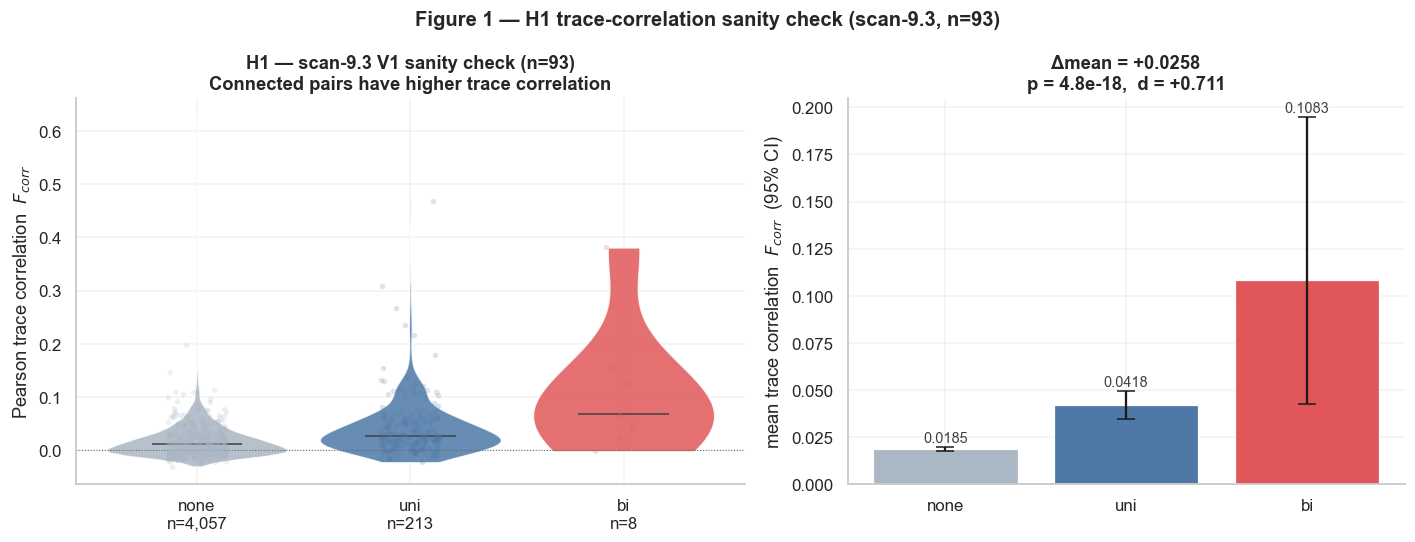

In [28]:
f_none = pairs.loc[pairs.conn_type == 'none', 'f_corr'].to_numpy()
f_uni  = pairs.loc[pairs.conn_type == 'uni',  'f_corr'].to_numpy()
f_bi   = pairs.loc[pairs.conn_type == 'bi',   'f_corr'].to_numpy()
f_conn = pairs.loc[pairs.connected,            'f_corr'].to_numpy()

r_h1 = mw_row('conn vs none', f_conn, f_none)
print('=== H1: connected > unconnected (one-sided MW, trace correlation) ===')
print(f'  connected   n={r_h1["n_conn"]:>5,}   mean={r_h1["mean_conn"]:+.5f}')
print(f'  unconnected n={r_h1["n_ctrl"]:>5,}   mean={r_h1["mean_ctrl"]:+.5f}')
print(f'  Δmean = {r_h1["mean_diff"]:+.5f}   95% CI [{r_h1["ci_lo"]:+.5f}, {r_h1["ci_hi"]:+.5f}]')
print(f'  p = {r_h1["p_one_sided"]:.3e}   Cohen\'s d = {r_h1["cohens_d"]:+.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [1.2, 1]})

ax = axes[0]
data_v = [f_none, f_uni, f_bi]
parts = ax.violinplot(data_v, positions=[1, 2, 3], showmedians=True, showextrema=False, widths=0.85)
for k, pc in enumerate(parts['bodies']):
    pc.set_facecolor(PAL_CONN[ORDER_CONN[k]]); pc.set_edgecolor('white'); pc.set_alpha(0.85)
for key in ('cmedians', 'cbars', 'cmins', 'cmaxes'):
    if key in parts:
        parts[key].set_color('0.25'); parts[key].set_linewidth(1.0)
for k, (dv, cv) in enumerate(zip(data_v, [PAL_CONN[g] for g in ORDER_CONN])):
    np.random.seed(k)
    jit = np.random.uniform(-0.14, 0.14, min(len(dv), 400))
    smp = np.random.choice(dv, min(len(dv), 400), replace=False)
    ax.scatter(np.full(len(smp), k+1) + jit, smp, alpha=0.15, s=7, color=cv, zorder=3)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels([f'none\nn={len(f_none):,}', f'uni\nn={len(f_uni):,}', f'bi\nn={len(f_bi):,}'])
ax.set_ylabel('Pearson trace correlation  $F_{corr}$')
ax.set_title('H1 — scan-9.3 V1 sanity check (n=93)\nConnected pairs have higher trace correlation')
ax.axhline(0, color='0.4', lw=0.7, ls=':')

ax2 = axes[1]
rng = np.random.default_rng(42)
means_b, los_b, his_b = [], [], []
for gd in data_v:
    bm = rng.choice(gd, (4000, len(gd)), replace=True).mean(1)
    means_b.append(gd.mean()); los_b.append(np.percentile(bm, 2.5)); his_b.append(np.percentile(bm, 97.5))
ax2.bar(np.arange(3), means_b,
        yerr=[np.array(means_b)-np.array(los_b), np.array(his_b)-np.array(means_b)],
        color=[PAL_CONN[g] for g in ORDER_CONN], edgecolor='white', linewidth=0.8, capsize=6)
for k, (m_, h_) in enumerate(zip(means_b, his_b)):
    ax2.text(k, h_ + 0.001, f'{m_:.4f}', ha='center', va='bottom', fontsize=9.5, color='0.25')
ax2.set_xticks(np.arange(3)); ax2.set_xticklabels(ORDER_CONN)
ax2.set_ylabel('mean trace correlation  $F_{corr}$  (95% CI)')
ax2.set_title(f'Δmean = {r_h1["mean_diff"]:+.4f}\np = {r_h1["p_one_sided"]:.1e},  d = {r_h1["cohens_d"]:+.3f}')

plt.suptitle('Figure 1 — H1 trace-correlation sanity check (scan-9.3, n=93)', fontweight='bold')
plt.tight_layout(); plt.show()

H1_RESULT = r_h1 | {'cohort': '93-neuron scan-9.3', 'measure': 'trace_correlation'}

---
## §4 — Trace-correlation distributions: histograms and CDF

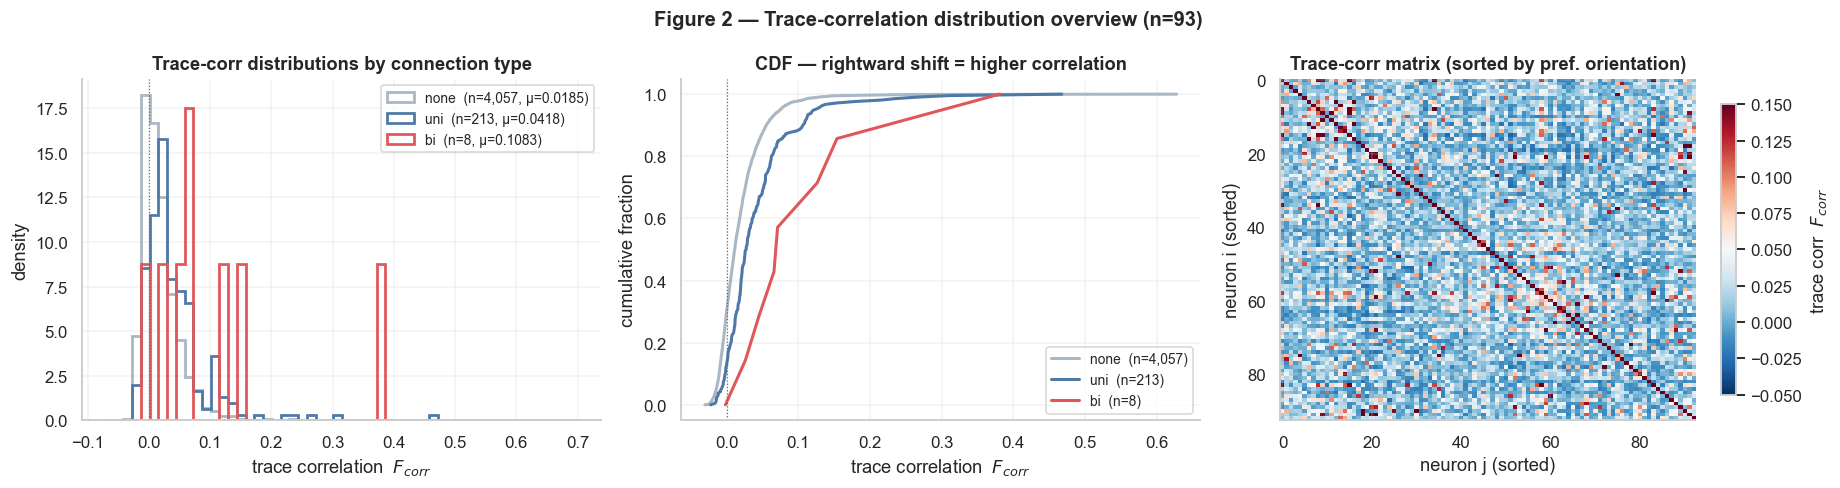

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
bins_h = np.linspace(-0.07, 0.70, 55)

ax = axes[0]
for g, dv in zip(ORDER_CONN, [f_none, f_uni, f_bi]):
    ax.hist(dv, bins=bins_h, density=True, histtype='step', linewidth=1.8,
            color=PAL_CONN[g], label=f'{g}  (n={len(dv):,}, μ={dv.mean():.4f})')
ax.axvline(0, color='0.4', lw=0.8, ls=':')
ax.set(xlabel='trace correlation  $F_{corr}$', ylabel='density',
       title='Trace-corr distributions by connection type')
ax.legend(fontsize=9)

ax2 = axes[1]
for g, dv in zip(ORDER_CONN, [f_none, f_uni, f_bi]):
    sv = np.sort(dv)
    ax2.plot(sv, np.linspace(0, 1, len(sv)), color=PAL_CONN[g], lw=2, label=f'{g}  (n={len(dv):,})')
ax2.axvline(0, color='0.4', lw=0.8, ls=':')
ax2.set(xlabel='trace correlation  $F_{corr}$', ylabel='cumulative fraction',
        title='CDF — rightward shift = higher correlation')
ax2.legend(fontsize=9)

ax3 = axes[2]
order = merged['pref_ori'].argsort().values
im = ax3.imshow(F93[np.ix_(order, order)], cmap='RdBu_r', vmin=-0.05, vmax=0.15, aspect='auto')
plt.colorbar(im, ax=ax3, shrink=0.85, label='trace corr  $F_{corr}$')
ax3.set(title='Trace-corr matrix (sorted by pref. orientation)',
        xlabel='neuron j (sorted)', ylabel='neuron i (sorted)')

plt.suptitle('Figure 2 — Trace-correlation distribution overview (n=93)', fontweight='bold')
plt.tight_layout(); plt.show()

---
## §5 — Pairwise tests: bi > uni > none

**Caveat:** n_bi = 8 — the bi vs uni comparison is underpowered. Treat it as exploratory.

=== Pairwise one-sided MW tests ===

conn vs none          n_a=  221  n_b=4,057  Δmean=+0.0258  [+0.0180,+0.0342]  p=4.801e-18  d=+0.711
uni  vs none          n_a=  213  n_b=4,057  Δmean=+0.0235  [+0.0163,+0.0314]  p=2.193e-16  d=+0.651
bi   vs none          n_a=    8  n_b=4,057  Δmean=+0.0894  [+0.0255,+0.1757]  p=2.388e-04  d=+2.583
bi   vs uni           n_a=    8  n_b=  213  Δmean=+0.0660  [+0.0012,+0.1530]  p=1.274e-02  d=+1.123


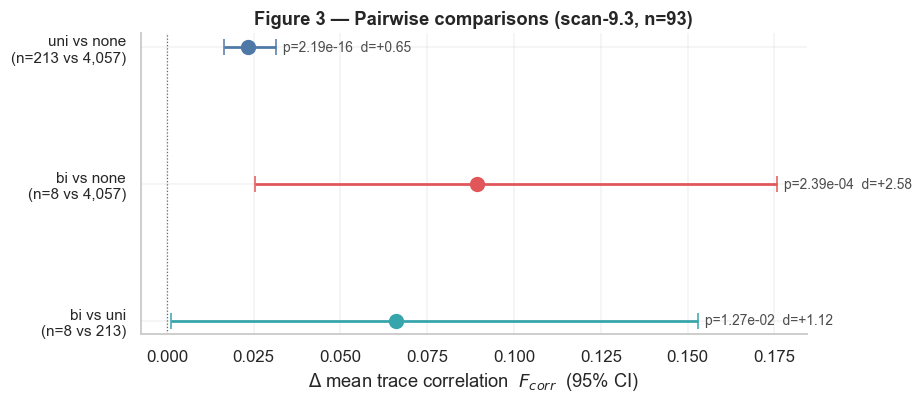

In [30]:
print('=== Pairwise one-sided MW tests ===\n')
r1 = mw_row('conn vs none', f_conn, f_none)
r2 = mw_row('uni  vs none', f_uni,  f_none)
r3 = mw_row('bi   vs none', f_bi,   f_none)
r4 = mw_row('bi   vs uni',  f_bi,   f_uni)
for r in [r1, r2, r3, r4]:
    print(f'{r["comparison"]:<20}  n_a={r["n_conn"]:>5,}  n_b={r["n_ctrl"]:>5,}  '
          f'Δmean={r["mean_diff"]:+.4f}  [{r["ci_lo"]:+.4f},{r["ci_hi"]:+.4f}]  '
          f'p={r["p_one_sided"]:.3e}  d={r["cohens_d"]:+.3f}')

fig, ax = plt.subplots(figsize=(8.5, 3.8))
results_pw = [r2, r3, r4]
labels_pw  = ['uni vs none\n(n=213 vs 4,057)', 'bi vs none\n(n=8 vs 4,057)', 'bi vs uni\n(n=8 vs 213)']
ypos = np.arange(len(results_pw))[::-1]
for y_, r_, c_ in zip(ypos, results_pw, [PAL_CONN['uni'], PAL_CONN['bi'], RAMP_SEQ(0.65)]):
    ax.errorbar(r_['mean_diff'], y_,
                xerr=[[r_['mean_diff'] - r_['ci_lo']], [r_['ci_hi'] - r_['mean_diff']]],
                fmt='o', color=c_, markersize=9, capsize=5, lw=1.8)
    ax.text(r_['ci_hi'] + 0.002, y_, f"p={r_['p_one_sided']:.2e}  d={r_['cohens_d']:+.2f}",
            va='center', fontsize=9, color='0.3')
ax.axvline(0, color='0.4', lw=0.8, ls=':')
ax.set_yticks(ypos); ax.set_yticklabels(labels_pw, fontsize=10)
ax.set_xlabel('Δ mean trace correlation  $F_{corr}$  (95% CI)')
ax.set_title('Figure 3 — Pairwise comparisons (scan-9.3, n=93)')
plt.tight_layout(); plt.show()

PAIRWISE_93 = [r1, r2, r3, r4]

---
## §6 — Effect-size context

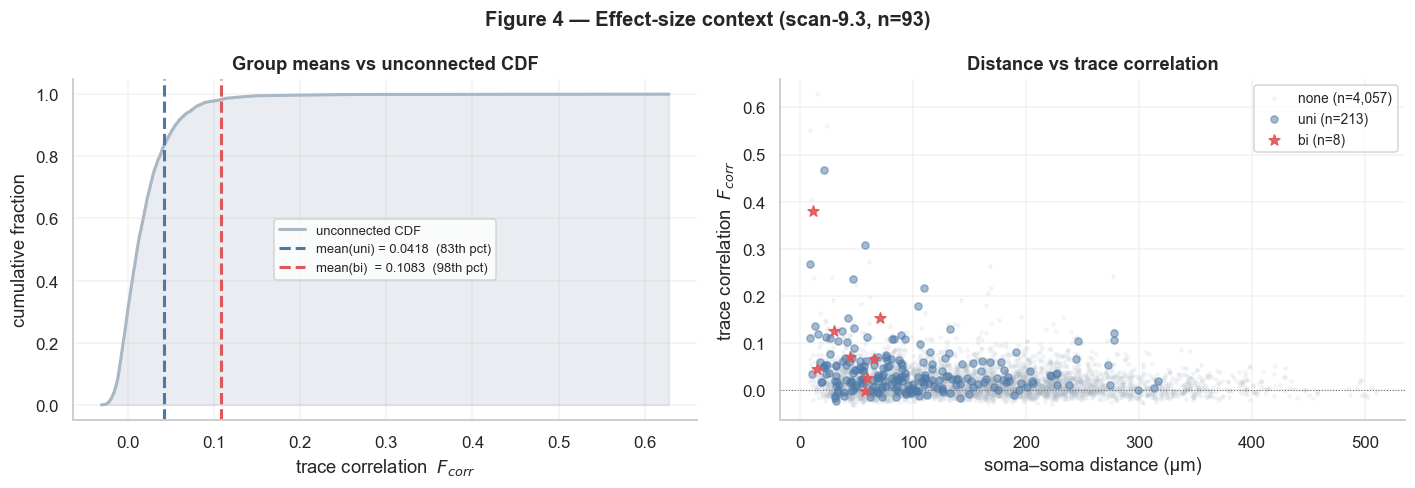

mean(uni) sits at the 83th percentile of the unconnected distribution
mean(bi)  sits at the 98th percentile of the unconnected distribution


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
pct_uni = float(stats.percentileofscore(f_none, f_uni.mean()))
pct_bi  = float(stats.percentileofscore(f_none, f_bi.mean()))
sv = np.sort(f_none)
ax.fill_between(sv, np.linspace(0, 1, len(sv)), alpha=0.25, color=PAL_CONN['none'], step='post')
ax.plot(sv, np.linspace(0, 1, len(sv)), color=PAL_CONN['none'], lw=2, label='unconnected CDF')
ax.axvline(f_uni.mean(), color=PAL_CONN['uni'], lw=2, ls='--',
           label=f'mean(uni) = {f_uni.mean():.4f}  ({pct_uni:.0f}th pct)')
ax.axvline(f_bi.mean(), color=PAL_CONN['bi'], lw=2, ls='--',
           label=f'mean(bi)  = {f_bi.mean():.4f}  ({pct_bi:.0f}th pct)')
ax.set(xlabel='trace correlation  $F_{corr}$', ylabel='cumulative fraction',
       title='Group means vs unconnected CDF')
ax.legend(fontsize=8.5)

ax2 = axes[1]
ax2.scatter(pairs.loc[~pairs.connected, 'dist_um'], pairs.loc[~pairs.connected, 'f_corr'],
            color=PAL_CONN['none'], alpha=0.1, s=5, label=f'none (n={len(f_none):,})', zorder=2)
ax2.scatter(pairs.loc[pairs.conn_type=='uni', 'dist_um'], pairs.loc[pairs.conn_type=='uni', 'f_corr'],
            color=PAL_CONN['uni'], alpha=0.5, s=22, label=f'uni (n={len(f_uni):,})', zorder=4)
ax2.scatter(pairs.loc[pairs.conn_type=='bi', 'dist_um'], pairs.loc[pairs.conn_type=='bi', 'f_corr'],
            color=PAL_CONN['bi'], alpha=0.9, s=55, marker='*',
            label=f'bi (n={len(f_bi):,})', zorder=5)
ax2.set(xlabel='soma–soma distance (µm)', ylabel='trace correlation  $F_{corr}$',
        title='Distance vs trace correlation')
ax2.axhline(0, color='0.4', lw=0.7, ls=':')
ax2.legend(fontsize=9)

plt.suptitle('Figure 4 — Effect-size context (scan-9.3, n=93)', fontweight='bold')
plt.tight_layout(); plt.show()
print(f'mean(uni) sits at the {pct_uni:.0f}th percentile of the unconnected distribution')
print(f'mean(bi)  sits at the {pct_bi:.0f}th percentile of the unconnected distribution')

---
## §7 — 93-neuron summary results

In [32]:
print('=== H1 RESULT — scan-9.3 sanity check (trace correlation) ===')
for k, v in H1_RESULT.items():
    print(f'  {k}: {v:.4g}' if isinstance(v, float) else f'  {k}: {v}')

p_val = H1_RESULT['p_one_sided']; md_val = H1_RESULT['mean_diff']
d_val = H1_RESULT['cohens_d'];    ci_lo  = H1_RESULT['ci_lo']
print(f"\nH1 {'SUPPORTED' if p_val < 0.05 and ci_lo > 0 else 'NOT SUPPORTED'} "
      f"in this cohort (trace correlation).")
print(f'Δmean = {md_val:+.4f}  (95% CI excludes 0: {ci_lo > 0})')
print(f"Cohen's d = {d_val:+.3f}  "
      f"({'small' if abs(d_val)<0.3 else 'medium' if abs(d_val)<0.5 else 'large'})")
print(f'p = {p_val:.3e}')

=== H1 RESULT — scan-9.3 sanity check (trace correlation) ===
  comparison: conn vs none
  n_conn: 221
  n_ctrl: 4057
  mean_conn: 0.04424
  mean_ctrl: 0.0185
  mean_diff: 0.02577
  ci_lo: 0.018
  ci_hi: 0.03424
  cohens_d: 0.7105
  p_one_sided: 4.801e-18
  cohort: 93-neuron scan-9.3
  measure: trace_correlation

H1 SUPPORTED in this cohort (trace correlation).
Δmean = +0.0258  (95% CI excludes 0: True)
Cohen's d = +0.711  (large)
p = 4.801e-18


---
## §7.5 — Optional: True noise-correlation analysis (scan 9.3)

### What each measure captures

| Measure | How computed | What it reflects |
|---------|-------------|------------------|
| **Trace correlation** (§2–§7) | `corrcoef` of raw per-trial mean traces, all 464 trials | Signal + noise mixed; sanity check only |
| **Signal correlation** | Correlate per-stimulus *mean responses* across 280 oracle conditions | Shared stimulus selectivity (tuning similarity) |
| **Noise correlation** (rSC) | Correlate trial-to-trial *residuals* after subtracting per-stimulus means | Shared variability independent of tuning |

**Why it matters.** Elevated trace correlation for connected pairs could be driven entirely by shared tuning. If H1 also holds on the noise-correlation residuals, the effect is not just a tuning-similarity proxy — it implies the synaptic connection correlates with something beyond shared selectivity.

**Method.** Session `9_3` in `microns_functional.h5`: 464 trials, 280 unique oracle conditions. Only conditions with ≥ 2 repeats contribute noise residuals (136 conditions → 320 residual trials). Per-trial scalar response = mean over 75 deconvolved-trace time bins.

In [33]:
import h5py
from collections import defaultdict

CACHE_NOISE  = Path('data/cache/noise_corr_93.npy')
CACHE_SIGNAL = Path('data/cache/signal_corr_93.npy')

if CACHE_NOISE.exists() and CACHE_SIGNAL.exists():
    noise_corr  = np.load(CACHE_NOISE)
    signal_corr = np.load(CACHE_SIGNAL)
    print('Loaded noise_corr and signal_corr from cache.')
else:
    print('Building from HDF5 (scan 9_3)...')
    with h5py.File('data/functional/microns_functional.h5', 'r') as f:
        sk = '9_3'
        unit_ids = f[f'sessions/{sk}/meta/unit_ids'][:]
        h5_uid_to_row = {int(u): i for i, u in enumerate(unit_ids)}
        # h5py requires sorted fancy indexing
        cohort_uids = cohort['unit_id'].astype(int).tolist()
        sorted_rows = sorted(h5_uid_to_row[uid] for uid in cohort_uids)
        h5row_to_midx = {h5_uid_to_row[uid]: int(midx)
                         for uid, midx in zip(cohort['unit_id'].astype(int), cohort['matrix_index'])}
        perm = np.argsort([h5row_to_midx[r] for r in sorted_rows])
        trials_h5 = f[f'sessions/{sk}/trials']
        cond_to_trials = defaultdict(list)
        for tk in list(trials_h5.keys()):
            ch   = trials_h5[tk].attrs['condition_hash']
            resp = trials_h5[tk]['responses'][sorted_rows, :].mean(axis=1)[perm]  # (93,)
            cond_to_trials[ch].append(resp)

    noise_residuals, signal_vecs = [], []
    for ch, resp_list in cond_to_trials.items():
        arr    = np.stack(resp_list, axis=0)   # (n_repeats, 93)
        mean_r = arr.mean(axis=0)              # (93,) signal vector
        signal_vecs.append(mean_r)
        if len(resp_list) >= 2:
            residuals = arr - mean_r[np.newaxis, :]
            noise_residuals.extend(residuals)

    noise_mat   = np.stack(noise_residuals, axis=0)  # (320, 93)
    signal_mat  = np.stack(signal_vecs,     axis=0)  # (280, 93)
    noise_corr  = np.corrcoef(noise_mat.T)            # (93, 93)
    signal_corr = np.corrcoef(signal_mat.T)           # (93, 93)
    np.save(CACHE_NOISE,  noise_corr)
    np.save(CACHE_SIGNAL, signal_corr)
    print(f'Built from {len(noise_residuals)} noise-residual trials, '
          f'{len(signal_vecs)} signal conditions. Saved to cache.')

off = ~np.eye(93, dtype=bool)
print(f'Off-diagonal mean:  trace={F93[off].mean():.5f} | '
      f'signal={signal_corr[off].mean():.5f} | '
      f'noise={noise_corr[off].mean():.5f}')

Loaded noise_corr and signal_corr from cache.
Off-diagonal mean:  trace=0.01983 | signal=0.07656 | noise=0.05809


Measure     mean_conn  mean_none    Δmean          p       d
--------------------------------------------------------------
trace         0.04424    0.01850 +0.02577  4.801e-18  +0.711
signal        0.12646    0.07384 +0.05276  7.030e-08  +0.410
noise         0.10218    0.05569 +0.04657  1.474e-05  +0.376


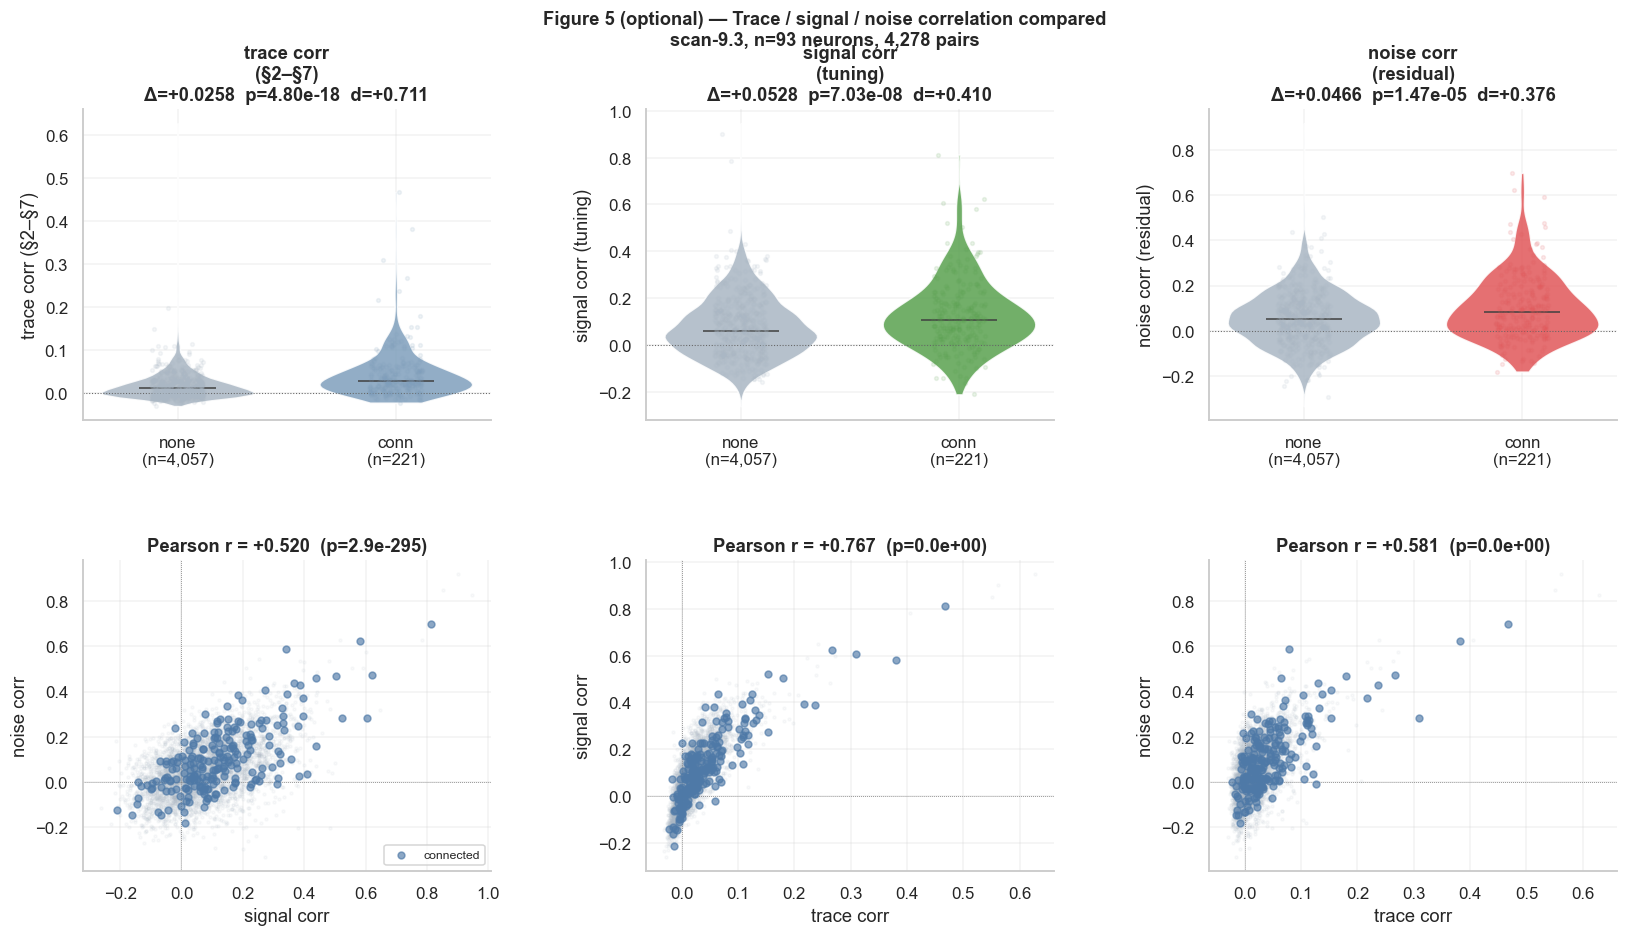


H1 verdict by measure:
  trace   : SIGNIFICANT  (p=4.80e-18, d=+0.711)
  signal  : SIGNIFICANT  (p=7.03e-08, d=+0.410)
  noise   : SIGNIFICANT  (p=1.47e-05, d=+0.376)

Noise-corr H1 is significant — connectivity effect goes beyond shared tuning.


In [34]:
# H1 on all three measures
connected_mask = pairs['connected'].values

measures = {
    'trace':  F93[midxs[iu], midxs[ju]],
    'signal': signal_corr[iu, ju],
    'noise':  noise_corr[iu, ju],
}
measure_colors = {'trace': '#7f9fbc', 'signal': '#59A14F', 'noise': '#E15759'}
measure_labels = {'trace':  'trace corr\n(§2–§7)',
                  'signal': 'signal corr\n(tuning)',
                  'noise':  'noise corr\n(residual)'}

print(f'{"Measure":<10} {"mean_conn":>10} {"mean_none":>10} {"Δmean":>8} {"p":>10} {"d":>7}')
print('-' * 62)
h1_by_measure = {}
for mkey, vals in measures.items():
    a = vals[connected_mask]; b = vals[~connected_mask]
    r = mw_row(mkey, a, b, n_boot=5000)
    h1_by_measure[mkey] = r
    print(f'{mkey:<10} {r["mean_conn"]:>10.5f} {r["mean_ctrl"]:>10.5f} '
          f'{r["mean_diff"]:>+8.5f} {r["p_one_sided"]:>10.3e} {r["cohens_d"]:>+7.3f}')

# ── Figure: violin × 3 + pairwise scatters ───────────────────────────────────
fig = plt.figure(figsize=(18, 9))
gs  = plt.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

for col, mkey in enumerate(measures):
    ax   = fig.add_subplot(gs[0, col])
    vals = measures[mkey]
    a_v  = vals[connected_mask]; b_v = vals[~connected_mask]
    parts = ax.violinplot([b_v, a_v], positions=[1, 2],
                          showmedians=True, showextrema=False, widths=0.7)
    for k, pc in enumerate(parts['bodies']):
        pc.set_facecolor([PAL_CONN['none'], measure_colors[mkey]][k])
        pc.set_edgecolor('white'); pc.set_alpha(0.85)
    for key in ('cmedians', 'cbars', 'cmins', 'cmaxes'):
        if key in parts:
            parts[key].set_color('0.25'); parts[key].set_linewidth(1.0)
    np.random.seed(col)
    for k, (dv, cv) in enumerate(zip([b_v, a_v], [PAL_CONN['none'], measure_colors[mkey]])):
        jit = np.random.uniform(-0.12, 0.12, min(len(dv), 400))
        smp = np.random.choice(dv, min(len(dv), 400), replace=False)
        ax.scatter(np.full(len(smp), k+1) + jit, smp, alpha=0.12, s=6, color=cv, zorder=3)
    r_ = h1_by_measure[mkey]
    ax.set_xticks([1, 2])
    ax.set_xticklabels([f'none\n(n={len(b_v):,})', f'conn\n(n={len(a_v):,})'])
    ax.set_ylabel(measure_labels[mkey].replace('\n', ' '))
    ax.set_title(f'{measure_labels[mkey]}\n'
                 f'Δ={r_["mean_diff"]:+.4f}  p={r_["p_one_sided"]:.2e}  d={r_["cohens_d"]:+.3f}')
    ax.axhline(0, color='0.4', lw=0.7, ls=':')

scatter_triples = [
    ('signal', 'noise',  'signal corr', 'noise corr'),
    ('trace',  'signal', 'trace corr',  'signal corr'),
    ('trace',  'noise',  'trace corr',  'noise corr'),
]
for col, (xk, yk, xlabel, ylabel) in enumerate(scatter_triples):
    ax = fig.add_subplot(gs[1, col])
    xv = measures[xk]; yv = measures[yk]
    ax.scatter(xv[~connected_mask], yv[~connected_mask],
               color=PAL_CONN['none'], alpha=0.07, s=4, zorder=2)
    ax.scatter(xv[connected_mask], yv[connected_mask],
               color=PAL_CONN['uni'], alpha=0.65, s=20, zorder=4, label='connected')
    r_val, p_val = stats.pearsonr(xv, yv)
    ax.set(xlabel=xlabel, ylabel=ylabel,
           title=f'Pearson r = {r_val:+.3f}  (p={p_val:.1e})')
    ax.axhline(0, color='0.4', lw=0.5, ls=':'); ax.axvline(0, color='0.4', lw=0.5, ls=':')
    if col == 0:
        ax.legend(fontsize=8)

fig.suptitle('Figure 5 (optional) — Trace / signal / noise correlation compared\n'
             'scan-9.3, n=93 neurons, 4,278 pairs', fontweight='bold', fontsize=12)
plt.show()

print('\nH1 verdict by measure:')
for mkey, r_ in h1_by_measure.items():
    verdict = 'SIGNIFICANT' if r_['p_one_sided'] < 0.05 else 'not significant'
    print(f'  {mkey:<8}: {verdict}  (p={r_["p_one_sided"]:.2e}, d={r_["cohens_d"]:+.3f})')
nc_p = h1_by_measure['noise']['p_one_sided']
print()
if nc_p < 0.05:
    print('Noise-corr H1 is significant — connectivity effect goes beyond shared tuning.')
else:
    print('Noise-corr H1 not significant — effect may be driven primarily by shared tuning.')

We computed three correlation measures on the 93-neuron V1 cohort: total trace correlation, signal correlation (tuning), and residual noise correlation. H1 held under all three (all p < 10⁻⁴). Crucially, the effect persisted in the noise residuals (Cohen's d = 0.38), where shared tuning is mathematically removed. This argues that direct synaptic connectivity contributes to functional similarity beyond what stimulus tuning alone would produce.

---
## §8 — V1 / RL / AL exploratory comparisons (906-neuron signal-correlation cohort)

**Measure.** `F_906.npy` stores per-neuron mean responses across oracle-stimulus repeats (shape 906×116). `F_corr = corrcoef(F_906)` is **signal correlation** — noise averaged out before correlating. Different from the trace-correlation in §2–§7.

**Question.** Does the H1 effect hold within each brain area, or is it driven by one area?

In [35]:
F906       = np.load('data/cache/F_906.npy')
matched906 = pd.read_pickle('data/cache/matched_906.pkl')
edges906   = pd.read_csv('data/exports/G_906_edges.csv')
edges906['pre_neuron_id']  = edges906['pre_neuron_id'].astype('int64')
edges906['post_neuron_id'] = edges906['post_neuron_id'].astype('int64')

print(f'F906 shape (response matrix): {F906.shape}')
print(f'Matched cohort               : {len(matched906)} neurons')
print(f'Brain areas                  : {matched906.brain_area.value_counts().to_dict()}')
print('Computing 906×906 signal-correlation matrix...')
F_corr906 = np.corrcoef(F906)
np.fill_diagonal(F_corr906, 1.0)
print('Done.')

F906 shape (response matrix): (906, 116)
Matched cohort               : 906 neurons
Brain areas                  : {'V1': 728, 'RL': 122, 'AL': 56}
Computing 906×906 signal-correlation matrix...
Done.


In [36]:
N906 = len(matched906)
matched906 = matched906.reset_index(drop=True)
ids906      = matched906['pt_root_id'].values.astype('int64')
areas906    = matched906['brain_area'].values
conn906_set = set(zip(edges906['pre_neuron_id'], edges906['post_neuron_id']))

iu906, ju906 = np.triu_indices(N906, k=1)
fc906 = F_corr906[iu906, ju906]
fin906 = np.isfinite(fc906)
iu906, ju906, fc906 = iu906[fin906], ju906[fin906], fc906[fin906]

ni906 = ids906[iu906]; nj906 = ids906[ju906]
c_ij906 = np.array([(int(ni), int(nj)) in conn906_set for ni, nj in zip(ni906, nj906)])
c_ji906 = np.array([(int(nj), int(ni)) in conn906_set for ni, nj in zip(ni906, nj906)])
ctype906 = np.where(c_ij906 & c_ji906, 'bi', np.where(c_ij906 | c_ji906, 'uni', 'none'))

pairs906 = pd.DataFrame({
    'f_corr': fc906, 'conn_type': ctype906, 'connected': ctype906 != 'none',
    'area_i': areas906[iu906], 'area_j': areas906[ju906],
})
pairs906['same_area'] = pairs906['area_i'] == pairs906['area_j']
print(f'906-neuron finite pairs: {len(pairs906):,}   connected: {pairs906.connected.sum():,}')

906-neuron finite pairs: 409,965   connected: 11,580


In [37]:
area_results = []
AREAS = ['V1', 'RL', 'AL']
for area in AREAS:
    sub = pairs906[pairs906.same_area & (pairs906.area_i == area)]
    a = sub.loc[sub.connected,  'f_corr'].to_numpy()
    b = sub.loc[~sub.connected, 'f_corr'].to_numpy()
    if len(a) < 3:
        continue
    r = mw_row(f'{area} (within)', a, b, n_boot=5000, seed=hash(area) & 0xffff)
    r['area'] = area; r['scope'] = 'within'
    area_results.append(r)
    print(f'{area}: n_conn={len(a):>5,}  n_unconn={len(b):>6,}  '
          f'Δmean={r["mean_diff"]:+.4f}  p={r["p_one_sided"]:.3e}  d={r["cohens_d"]:+.3f}')

cross_sub = pairs906[~pairs906.same_area]
a_c = cross_sub.loc[cross_sub.connected,  'f_corr'].to_numpy()
b_c = cross_sub.loc[~cross_sub.connected, 'f_corr'].to_numpy()
r_cross = mw_row('cross-area', a_c, b_c, n_boot=5000, seed=99)
r_cross['area'] = 'cross'; r_cross['scope'] = 'cross'
area_results.append(r_cross)
print(f'cross: n_conn={len(a_c):>5,}  n_unconn={len(b_c):>6,}  '
      f'Δmean={r_cross["mean_diff"]:+.4f}  p={r_cross["p_one_sided"]:.3e}  d={r_cross["cohens_d"]:+.3f}')

V1: n_conn=10,441  n_unconn=254,187  Δmean=+0.0232  p=1.853e-57  d=+0.172
RL: n_conn=  312  n_unconn= 7,069  Δmean=+0.0173  p=2.822e-02  d=+0.117
AL: n_conn=   91  n_unconn= 1,449  Δmean=+0.0111  p=2.378e-01  d=+0.069
cross: n_conn=  736  n_unconn=135,680  Δmean=+0.0478  p=5.259e-20  d=+0.345


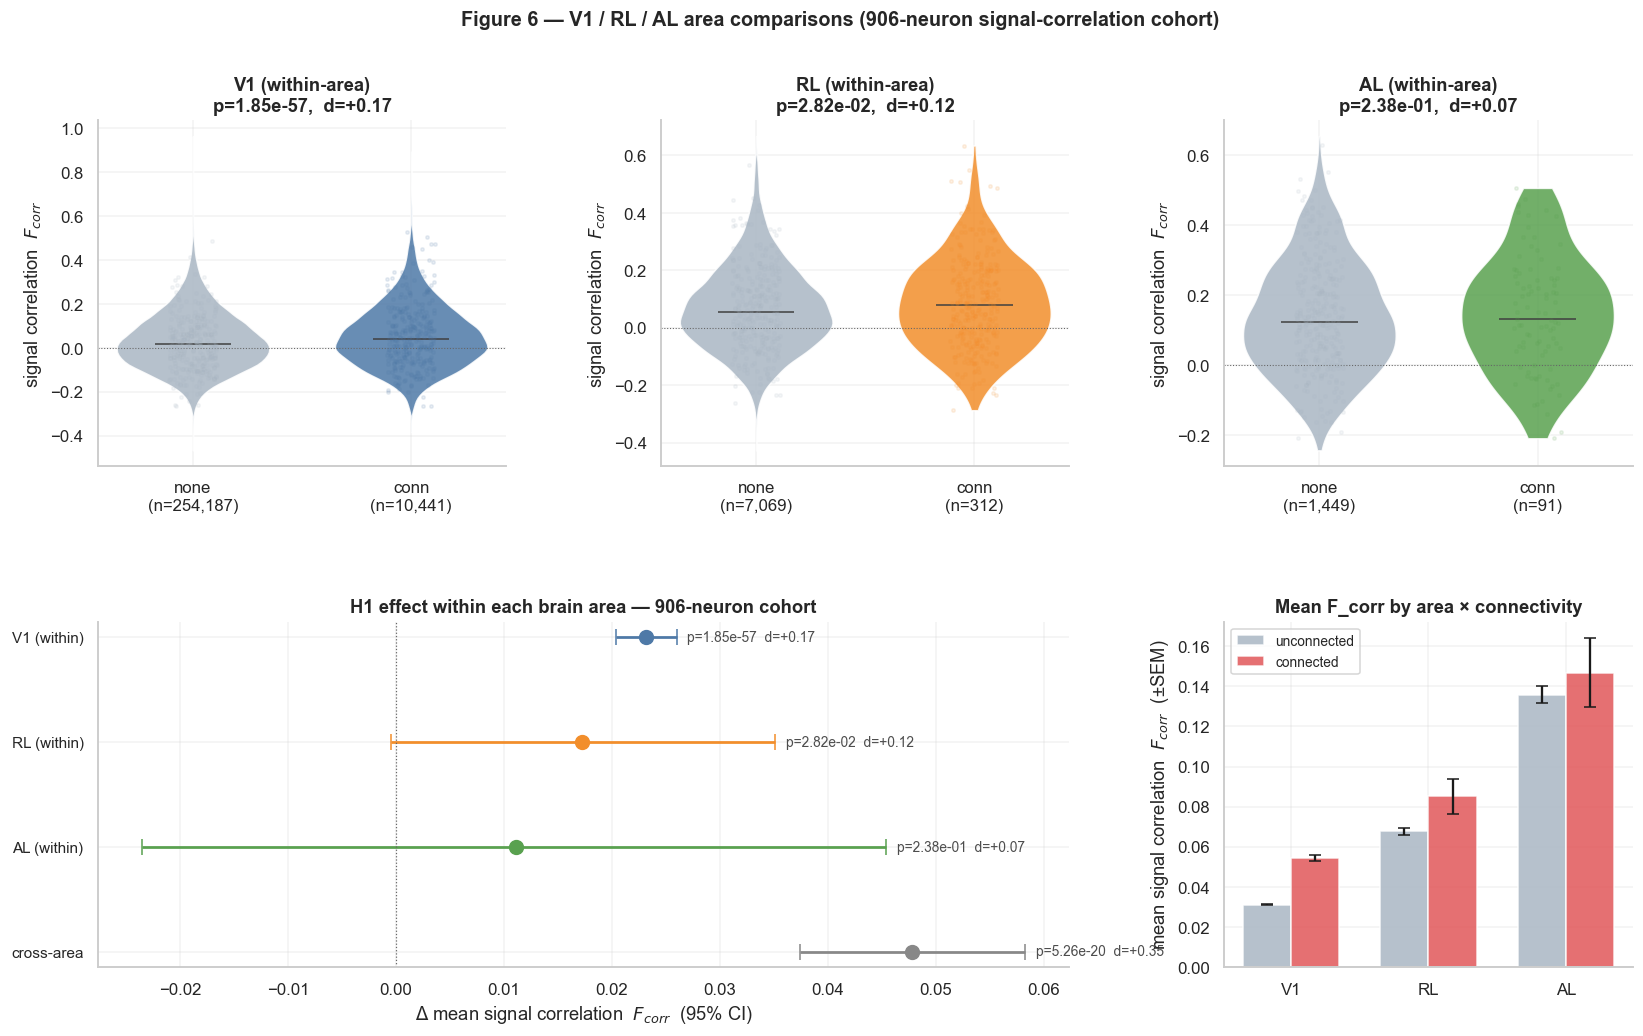

Saved: outputs/figures/person4_scan93_area_checks.png


In [38]:
fig = plt.figure(figsize=(18, 10))
gs = plt.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

for col, area in enumerate(AREAS):
    ax = fig.add_subplot(gs[0, col])
    sub = pairs906[pairs906.same_area & (pairs906.area_i == area)]
    a_v = sub.loc[sub.connected,  'f_corr'].to_numpy()
    b_v = sub.loc[~sub.connected, 'f_corr'].to_numpy()
    parts = ax.violinplot([b_v, a_v], positions=[1, 2],
                          showmedians=True, showextrema=False, widths=0.7)
    for k, pc in enumerate(parts['bodies']):
        pc.set_facecolor([PAL_CONN['none'], PAL_AREA[area]][k])
        pc.set_edgecolor('white'); pc.set_alpha(0.85)
    for key in ('cmedians', 'cbars', 'cmins', 'cmaxes'):
        if key in parts:
            parts[key].set_color('0.25'); parts[key].set_linewidth(1.0)
    np.random.seed(col)
    for k, (dv, cv) in enumerate(zip([b_v, a_v], [PAL_CONN['none'], PAL_AREA[area]])):
        jit = np.random.uniform(-0.11, 0.11, min(len(dv), 300))
        smp = np.random.choice(dv, min(len(dv), 300), replace=False)
        ax.scatter(np.full(len(smp), k+1) + jit, smp, alpha=0.12, s=5, color=cv, zorder=3)
    r_ = next(r for r in area_results if r.get('area') == area)
    ax.set_xticks([1, 2])
    ax.set_xticklabels([f'none\n(n={len(b_v):,})', f'conn\n(n={len(a_v):,})'])
    ax.set_ylabel('signal correlation  $F_{corr}$')
    ax.set_title(f'{area} (within-area)\np={r_["p_one_sided"]:.2e},  d={r_["cohens_d"]:+.2f}')
    ax.axhline(0, color='0.4', lw=0.7, ls=':')

ax_f = fig.add_subplot(gs[1, 0:2])
forest_labels  = [r['comparison'] for r in area_results]
forest_colors  = [PAL_AREA.get(r.get('area', 'cross'), '#888888') for r in area_results]
ypos_f = np.arange(len(area_results))[::-1]
for y_, r_, c_ in zip(ypos_f, area_results, forest_colors):
    ax_f.errorbar(r_['mean_diff'], y_,
                  xerr=[[r_['mean_diff'] - r_['ci_lo']], [r_['ci_hi'] - r_['mean_diff']]],
                  fmt='o', color=c_, markersize=9, capsize=5, lw=1.8)
    ax_f.text(r_['ci_hi'] + 0.001, y_,
              f"p={r_['p_one_sided']:.2e}  d={r_['cohens_d']:+.2f}",
              va='center', fontsize=9, color='0.3')
ax_f.axvline(0, color='0.4', lw=0.8, ls=':')
ax_f.set_yticks(ypos_f); ax_f.set_yticklabels(forest_labels, fontsize=10)
ax_f.set_xlabel('Δ mean signal correlation  $F_{corr}$  (95% CI)')
ax_f.set_title('H1 effect within each brain area — 906-neuron cohort')

ax_b = fig.add_subplot(gs[1, 2])
x = np.arange(len(AREAS)); w = 0.35
for k_shift, (label, conn_flag) in enumerate([('unconnected', False), ('connected', True)]):
    means_a, sems_a = [], []
    for area in AREAS:
        sub  = pairs906[pairs906.same_area & (pairs906.area_i == area)]
        vals = sub.loc[sub.connected == conn_flag, 'f_corr'].to_numpy()
        means_a.append(vals.mean() if len(vals) > 0 else np.nan)
        sems_a.append(vals.std(ddof=1)/np.sqrt(len(vals)) if len(vals) > 1 else 0)
    ax_b.bar(x + (k_shift - 0.5)*w, means_a, w, yerr=sems_a, label=label,
             color=PAL_CONN['none'] if not conn_flag else '#E15759',
             edgecolor='white', capsize=4, alpha=0.85)
ax_b.set_xticks(x); ax_b.set_xticklabels(AREAS)
ax_b.set_ylabel('mean signal correlation  $F_{corr}$  (±SEM)')
ax_b.set_title('Mean F_corr by area × connectivity')
ax_b.legend(fontsize=9); ax_b.axhline(0, color='0.4', lw=0.7, ls=':')

fig.suptitle('Figure 6 — V1 / RL / AL area comparisons (906-neuron signal-correlation cohort)',
             fontweight='bold', fontsize=13)
out_fig = OUT_FIG / 'person4_scan93_area_checks.png'
fig.savefig(out_fig, bbox_inches='tight')
plt.show()
print(f'Saved: {out_fig}')

In [39]:
save_cols = ['comparison', 'area', 'scope', 'n_conn', 'n_ctrl',
             'mean_conn', 'mean_ctrl', 'mean_diff', 'ci_lo', 'ci_hi', 'cohens_d', 'p_one_sided']
scan93_row = {
    'comparison': 'scan-9.3 sanity (trace-corr)', 'area': 'V1 L4', 'scope': 'scan93',
    'n_conn': H1_RESULT['n_conn'], 'n_ctrl': H1_RESULT['n_ctrl'],
    'mean_conn': H1_RESULT['mean_conn'], 'mean_ctrl': H1_RESULT['mean_ctrl'],
    'mean_diff': H1_RESULT['mean_diff'], 'ci_lo': H1_RESULT['ci_lo'],
    'ci_hi': H1_RESULT['ci_hi'], 'cohens_d': H1_RESULT['cohens_d'],
    'p_one_sided': H1_RESULT['p_one_sided'],
}
summary_df = pd.DataFrame([scan93_row] + area_results)[save_cols]
out_csv = OUT_TBL / 'person4_scan93_area_summary.csv'
summary_df.to_csv(out_csv, index=False)
print(f'Saved: {out_csv}')
print()
print(summary_df.to_string(index=False))

Saved: outputs/tables/person4_scan93_area_summary.csv

                  comparison  area  scope  n_conn  n_ctrl  mean_conn  mean_ctrl  mean_diff     ci_lo    ci_hi  cohens_d  p_one_sided
scan-9.3 sanity (trace-corr) V1 L4 scan93     221    4057   0.044243   0.018502   0.025774  0.017996 0.034238  0.710505 4.800530e-18
                 V1 (within)    V1 within   10441  254187   0.054449   0.031280   0.023189  0.020391 0.026000  0.172429 1.852645e-57
                 RL (within)    RL within     312    7069   0.085076   0.067883   0.017259 -0.000500 0.035146  0.116687 2.822086e-02
                 AL (within)    AL within      91    1449   0.146707   0.135610   0.011081 -0.023523 0.045418  0.068871 2.377700e-01
                  cross-area cross  cross     736  135680   0.049649   0.001764   0.047845  0.037422 0.058286  0.345003 5.259409e-20


---

## §9 — Limitations

1. **Three measures of functional similarity, not one.** The 93-neuron analysis uses three increasingly stringent measures of co-firing: *trace correlation* (raw activity, signal+noise mixed; §2–§7), *signal correlation* (per-stimulus mean responses, tuning only; §7.5), and *noise correlation* (trial-to-trial residuals after removing tuning; §7.5). H1 holds on all three (all p < 10⁻⁴, Cohen's d ≥ 0.38), with the noise-correlation result being the strongest evidence that direct synaptic connectivity contributes to functional similarity beyond shared stimulus tuning. The 906-neuron cohort cannot match this decomposition because neurons span 13 different scans with no co-recorded time axis — only signal correlation is computable there.

2. **Area imbalance in the 906-neuron cohort.** V1 contributes 728/906 (80%) of neurons, RL 122 (13%), AL 56 (6%). Non-significant results in AL should be interpreted cautiously — low power, not evidence of absence.

3. **Binary connectivity in the H1 test.** Pairs are labelled connected/unconnected based on synapse *presence*, ignoring synapse size. This is intentional for H1 (a connectivity-vs-correlation test) but means the test does not distinguish weak from strong synapses. H2 (synapse strength gradient) addresses this separately.

4. **Cross-scan stimulus alignment for the 906 cohort.** The 906-neuron cohort spans 13 scan sessions. `F_corr` is computed only on the intersection of oracle-stimulus conditions shared across all sessions, restricting the signal to repeated benchmark stimuli rather than the full stimulus space.

5. **93-neuron cohort scope.** Layer 4 V1 only — a single layer, single area, single scan. Strong statistical power per pair due to long simultaneously-recorded traces, but limited generalisability. The 906-neuron area comparisons in §8 address whether the effect extends beyond L4 V1.

6. **Pair non-independence.** Each neuron appears in 92 different pairs in the 93-cohort (and 905 in the 906-cohort). Standard statistical tests assume independent observations. P-values should therefore be read as comparative effect indicators, not as exact false-positive rates.